# Predicting Antimicrobial Resistance Patterns in Kazakhstan Using Zero-Shot Machine Learning

This notebook implements a zero-shot machine learning framework to predict antimicrobial resistance (AMR) patterns in Kazakhstan using three global clinical surveillance databases enriched with macroeconomic indicators.

**Key design:** Kazakhstan is fully excluded from model training. The model generalizes to Kazakhstan using macroeconomic proxy features (GDP, health expenditure, population density), enabling zero-shot prediction in the absence of local clinical training data.

---

## Dataset Sources

| Dataset | Description | Kaggle Path |
|---|---|---|
| ATLAS | Global AMR surveillance (Pfizer) | `data/atlas.csv` |
| SIDERO-WT | Global AMR surveillance (Shionogi) | `data/sidero_wt.xlsx` |
| KEYSTONE | Global AMR surveillance | `data/keystone.xlsx` |
| World Bank Macro (Global) | GDP, health expenditure, population density | `data/worldbank/` |
| World Bank Macro (Kazakhstan) | Kazakhstan-specific macro indicators | `data/worldbank-kz/` |
| Kazakhstan DID | Antibiotic consumption DDD per 1000/day (2017–2023) | `data/kazakhstan_antibiotics_did_2017_2023.csv` |

> ATLAS, SIDERO-WT, and KEYSTONE were obtained via formal data request through [vivli.org](https://vivli.org).
> World Bank indicators used: NY.GDP.PCAP.CD · SH.XPD.CHEX.GD.ZS · EN.POP.DNST

---

## Notebook Structure
1. Setup & Dependencies
2. Data Loading & Harmonization
3. Leakage Audit
4. Global Macroeconomic Feature Engineering
5. Feature Set Definition
6. Domain Split
7. Model Training (RF · XGBoost · LightGBM)
8. LOCO Validation
9. 5-Fold Time-Aware Cross-Validation
10. Kazakhstan Macroeconomic Data Processing
11. Zero-Shot Prediction for Kazakhstan
12. Results & Visualization


## 1. Setup & Dependencies

In [1]:
import os
import pickle
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    classification_report, ConfusionMatrixDisplay
)
from sklearn.model_selection import GroupKFold
import xgboost as xgb
import lightgbm as lgb
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore')
os.makedirs('outputs/', exist_ok=True)
print("Environment ready.")

Environment ready.


## 2. Data Loading & Harmonization

Three global AMR surveillance databases are loaded, standardized, and merged into a single unified dataset.

**Resistance encoding:**
- SIR: R=1, S=0, I=discarded (clinically ambiguous)
- MIC: binary via simplified CLSI/EUCAST breakpoints
- Unique isolate IDs: `{SOURCE}_{original_id}_{year}` to prevent cross-database collisions


In [2]:
ATLAS_PATH    = 'data/atlas.csv'
SIDERO_PATH   = 'data/sidero_wt.xlsx'
KEYSTONE_PATH = 'data/keystone.xlsx'
COMBINED_OUTPUT = 'outputs/combined_dataset.csv'

def parse_sir_to_binary(sir_str):
    """SIR → binary. Intermediate (I) discarded as clinically ambiguous."""
    if pd.isna(sir_str):
        return np.nan
    s = str(sir_str).strip().upper()
    if s in ['R', 'RESISTANT']:   return 1
    if s in ['S', 'SUSCEPTIBLE']: return 0
    return np.nan

def clean_mic_value(val):
    """Normalize MIC string to float."""
    if pd.isna(val): return np.nan
    val = str(val).strip().replace(',', '.')
    for sym in ['<=', '≤', '>=', '≥']:
        val = val.replace(sym, '')
    if '>' in val:
        try: return float(val.replace('>', '').strip()) + 0.0001
        except: return np.nan
    try: return float(val.strip())
    except: return np.nan

def parse_mic_to_binary(mic_val, antibiotic):
    """MIC → binary using simplified CLSI/EUCAST breakpoints."""
    mic = clean_mic_value(mic_val)
    if pd.isna(mic): return np.nan
    thresholds = {
        'Meropenem': 4, 'Imipenem': 4, 'Ceftazidime': 8,
        'Ciprofloxacin': 1, 'Colistin': 4, 'Amikacin': 16,
        'Gentamicin': 8, 'Cefepime': 8,
    }
    return 1 if mic > thresholds.get(antibiotic, 8) else 0

def assign_unique_isolate_id(df, data_source):
    """Composite isolate ID: {source}_{original_id}_{year} — prevents cross-database collisions."""
    if data_source == 'ATLAS' and 'Isolate Id' in df.columns:
        df['original_id'] = df['Isolate Id'].astype(str).str.strip()
    elif data_source == 'KEYSTONE' and 'Collection Number' in df.columns:
        df['original_id'] = df['Collection Number'].astype(str).str.strip()
    else:
        df['original_id'] = df.index.astype(str)
    df['isolate_id'] = data_source + '_' + df['original_id'] + '_' + df['year'].fillna(0).astype(int).astype(str)
    return df

def process_dataset(path, data_source, chunksize=250000):
    print(f"Processing {data_source}...")
    is_csv = path.endswith('.csv')
    reader = pd.read_csv if is_csv else pd.read_excel
    chunks = reader(path, chunksize=chunksize, low_memory=False) if is_csv else [reader(path)]
    processed = []

    for i, chunk in enumerate(chunks):
        print(f"  Chunk {i+1}: {len(chunk)} rows")
        rename = {
            'Isolate Id': 'original_id_temp', 'Species': 'organism',
            'Country': 'country', 'Year': 'year',
            'Organism Name': 'organism', 'Year Collected': 'year',
            'Organism': 'organism', 'Study Year': 'year',
            'Collection Number': 'original_id_temp',
        }
        chunk = chunk.rename(columns=rename)
        for col in ['country', 'year', 'organism']:
            if col not in chunk.columns:
                chunk[col] = 'Unknown' if col != 'year' else np.nan
        chunk['country']  = chunk['country'].astype(str).str.strip()
        chunk['organism'] = chunk['organism'].astype(str).str.strip()
        chunk['year']     = pd.to_numeric(chunk['year'], errors='coerce').astype('Int16')
        chunk = assign_unique_isolate_id(chunk, data_source)

        sir_cols = [c for c in chunk.columns if c.endswith('_I')]
        mic_cols = [c for c in chunk.columns if c not in
                    sir_cols + ['isolate_id', 'country', 'year', 'organism', 'original_id', 'original_id_temp']]
        value_vars   = sir_cols if sir_cols else mic_cols
        melt_varname = 'antibiotic_raw' if sir_cols else 'antibiotic'
        if not value_vars: continue

        long = pd.melt(chunk, id_vars=['isolate_id', 'country', 'year', 'organism'],
                       value_vars=value_vars, var_name=melt_varname, value_name='test_result')

        if sir_cols:
            long['antibiotic'] = long['antibiotic_raw'].str.replace('_I$', '', regex=True).str.strip()
            long['resistance']  = long['test_result'].apply(parse_sir_to_binary)
        else:
            long['antibiotic'] = long['antibiotic'].str.strip()
            long['resistance']  = long.apply(lambda r: parse_mic_to_binary(r['test_result'], r['antibiotic']), axis=1)

        long = long.dropna(subset=['resistance'])
        long['resistance']   = long['resistance'].astype('int8')
        long['data_source']  = data_source
        processed.append(long)

    result = pd.concat(processed, ignore_index=True)
    print(f"  → {len(result):,} rows")
    return result

atlas    = process_dataset(ATLAS_PATH,    'ATLAS')
sidero   = process_dataset(SIDERO_PATH,   'SIDERO-WT')
keystone = process_dataset(KEYSTONE_PATH, 'KEYSTONE')

combined = pd.concat([atlas, sidero, keystone], ignore_index=True)
combined.to_csv(COMBINED_OUTPUT, index=False)
print(f"\nCombined: {len(combined):,} rows | {combined['isolate_id'].nunique():,} unique isolates")
print(f"Class distribution:\n{combined['resistance'].value_counts(normalize=True).round(4)}")

Processing ATLAS...
  Chunk 1: 250000 rows
  Chunk 2: 250000 rows
  Chunk 3: 250000 rows
  Chunk 4: 216805 rows
  → 10,717,988 rows
Processing SIDERO-WT...
  Chunk 1: 47615 rows
  → 435,633 rows
Processing KEYSTONE...
  Chunk 1: 90208 rows
  → 1,296,305 rows

Combined: 12,449,926 rows | 1,100,391 unique isolates
Class distribution:
resistance
0    0.8036
1    0.1964
Name: proportion, dtype: float64


## 3. Leakage Audit

Temporal split: Train ≤ 2020, Validation 2021–2022, Test > 2022.
Explicit audit confirms zero isolate ID overlap across all three partitions.


In [4]:
full_df = pd.read_csv('outputs/combined_dataset.csv', low_memory=False)
full_df_sorted = full_df.sort_values('year').reset_index(drop=True)

TRAIN_CUTOFF, VAL_CUTOFF = 2020, 2022

train = full_df_sorted[full_df_sorted['year'] <= TRAIN_CUTOFF]
val   = full_df_sorted[(full_df_sorted['year'] > TRAIN_CUTOFF) & (full_df_sorted['year'] <= VAL_CUTOFF)]
test  = full_df_sorted[full_df_sorted['year'] > VAL_CUTOFF]

print(f"Train : {len(train):,} rows (≤ {TRAIN_CUTOFF})")
print(f"Val   : {len(val):,} rows ({TRAIN_CUTOFF+1}–{VAL_CUTOFF})")
print(f"Test  : {len(test):,} rows (> {VAL_CUTOFF})")

train_ids, val_ids, test_ids = set(train['isolate_id']), set(val['isolate_id']), set(test['isolate_id'])
print(f"\nTrain-Val overlap  : {len(train_ids & val_ids):,}")
print(f"Train-Test overlap : {len(train_ids & test_ids):,}")
print(f"Val-Test overlap   : {len(val_ids & test_ids):,}")
print("\nLeakage audit PASSED." if len(train_ids & test_ids) == 0 else "\nWARNING: Leakage detected.")

Train : 9,755,320 rows (≤ 2020)
Val   : 1,892,959 rows (2021–2022)
Test  : 801,647 rows (> 2022)

Train-Val overlap  : 0
Train-Test overlap : 0
Val-Test overlap   : 0

Leakage audit PASSED.


## 4. Global Macroeconomic Feature Engineering

World Bank indicators (GDP per capita, health expenditure % GDP, population density) and global antibiotic consumption (DDD/1000/day) are merged into the global dataset by country and year.

Missing values are imputed using forward fill then backward fill within each country group, with the global column mean applied as a fallback for countries with no data across any year.

Log transformations are applied to GDP per capita and antibiotic consumption to reduce right-skew.


In [5]:
POP_DENSITY_PATH      = 'data/worldbank/API_EN.POP.DNST_DS2_en_csv_v2_275.csv'
GDP_PCAP_PATH         = 'data/worldbank/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_31.csv'
HEALTH_GDP_PATH       = 'data/worldbank/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_938.csv'
CONSUMPTION_PATH      = 'data/antibiotic-consumption-rate.csv'
GLOBAL_DID_CLASS_PATH = 'data/antibiotic_consumption_clean.csv'

def wb_long_format(path, value_col_name):
    """Parse World Bank CSV (wide format) → long format keyed by country and year."""
    if not os.path.exists(path):
        print(f"  [MISSING] {path}")
        return pd.DataFrame()
    df = pd.read_csv(path, skiprows=4, low_memory=False)
    df.columns = df.columns.str.strip()
    if 'Country Name' not in df.columns:
        print(f"  [ERROR] 'Country Name' missing in {path}")
        return pd.DataFrame()
    year_cols = [c for c in df.columns if c.strip().isdigit() and int(c.strip()) >= 2000]
    df_long = pd.melt(df, id_vars=['Country Name'], value_vars=year_cols,
                      var_name='year', value_name=value_col_name)
    df_long['year'] = df_long['year'].astype(int)
    df_long = df_long.rename(columns={'Country Name': 'country'})
    df_long[value_col_name] = pd.to_numeric(df_long[value_col_name], errors='coerce')
    result = df_long[['country', 'year', value_col_name]].dropna(subset=[value_col_name])
    print(f"  {value_col_name}: {len(result):,} rows, {result['country'].nunique()} countries")
    return result

# ── World Bank macros ─────────────────────────────────────────────────────────
print("Loading World Bank indicators...")
df_pop    = wb_long_format(POP_DENSITY_PATH, 'population_density_per_sq_km')
df_gdp    = wb_long_format(GDP_PCAP_PATH,    'gdp_per_capita_usd')
df_health = wb_long_format(HEALTH_GDP_PATH,  'health_expenditure_pct_gdp')

macro_df = df_gdp.copy()
for df_temp in [df_pop, df_health]:
    macro_df = macro_df.merge(df_temp, on=['country', 'year'], how='outer')

COUNTRY_MAP = {
    'United States': 'USA', 'United States of America': 'USA',
    'Russian Federation': 'Russia', 'Korea, Rep.': 'South Korea',
}
macro_df['country']  = macro_df['country'].replace(COUNTRY_MAP)
full_df['country']   = full_df['country'].replace(COUNTRY_MAP)

# Drop any pre-existing feature columns
drop_cols = [
    'gdp_per_capita_usd', 'population_density_per_sq_km', 'health_expenditure_pct_gdp',
    'consumption_ddd_per_1000_day', 'consumption_ddd_total', 'consumption_did_per_class',
    'log_gdp_per_capita', 'log_consumption_ddd', 'log_consumption_did_per_class',
    'antibiotic_class',
]
full_df = full_df.drop(columns=[c for c in drop_cols if c in full_df.columns])
full_df = full_df.merge(macro_df, on=['country', 'year'], how='left')

#Total antibiotic consumption
print("\nLoading total consumption...")
try:
    df_cons = pd.read_csv(CONSUMPTION_PATH)
    df_cons = df_cons.rename(columns={
        'Entity': 'country',
        'Year':   'year',
        'Defined daily doses of antibiotics and antituberculosis drugs used per 1,000 inhabitants per day': 'consumption_ddd_total'
    })
    df_cons = df_cons[['country', 'year', 'consumption_ddd_total']].copy()
    df_cons['country'] = df_cons['country'].replace({'Russian Federation': 'Russia', 'United States': 'USA'})
    full_df = full_df.merge(df_cons, on=['country', 'year'], how='left')
    print("  → OK")
except Exception as e:
    print(f"  → FAILED: {e}")
    full_df['consumption_ddd_total'] = np.nan

#Per-class DDD
print("\nLoading per-class DDD...")
did_raw = pd.read_csv(GLOBAL_DID_CLASS_PATH)
DID_COUNTRY_MAP = {
    'Us': 'USA', 'Uk': 'United Kingdom', 'Uae': 'United Arab Emirates',
    'Korea': 'South Korea', 'Russian Federation': 'Russia',
}
did_raw['country'] = did_raw['country'].replace(DID_COUNTRY_MAP)
did_class = (did_raw[['country', 'year', 'antibiotic_class', 'consumption_DID']]
             .copy()
             .rename(columns={'consumption_DID': 'consumption_did_per_class'}))

# Full antibiotic → class map
ANTIBIOTIC_TO_CLASS_MAP = {
    # Carbapenems
    'Meropenem': 'Carbapenems', 'Imipenem': 'Carbapenems',
    'Doripenem': 'Carbapenems', 'Ertapenem': 'Carbapenems',
    # Fluoroquinolones
    'Ciprofloxacin': 'Fluoroquinolones', 'Levofloxacin': 'Fluoroquinolones',
    'Moxifloxacin': 'Fluoroquinolones',  'Ofloxacin': 'Fluoroquinolones',
    'Norfloxacin': 'Fluoroquinolones',
    # Cephalosporins
    'Ceftazidime': 'Cephalosporins',  'Cefepime': 'Cephalosporins',
    'Ceftriaxone': 'Cephalosporins',  'Cefixime': 'Cephalosporins',
    'Cefazolin': 'Cephalosporins',    'Cefotaxime': 'Cephalosporins',
    'Cefuroxime': 'Cephalosporins',   'Cefpodoxime': 'Cephalosporins',
    'Cefoxitin': 'Cephalosporins',    'Ceftolozane': 'Cephalosporins',
    # Aminoglycosides
    'Amikacin': 'Aminoglycosides',   'Gentamicin': 'Aminoglycosides',
    'Kanamycin': 'Aminoglycosides',  'Tobramycin': 'Aminoglycosides',
    'Netilmicin': 'Aminoglycosides',
    # Penicillins
    'Ampicillin': 'Penicillins',
    'Amoxicillin- clavulanic acid': 'Penicillins',
    'Amoxycillin clavulanate': 'Penicillins',
    'Penicillin': 'Penicillins',
    'Piperacillin': 'Penicillins',
    'Piperacillin-tazobactam': 'Penicillins',
    'Oxacillin': 'Penicillins',
    # Macrolides
    'Azithromycin': 'Macrolides',   'Clarithromycin': 'Macrolides',
    'Erythromycin': 'Macrolides',
    # Glycopeptides
    'Vancomycin': 'Glycopeptides',  'Teicoplanin': 'Glycopeptides',
    # Tetracyclines
    'Doxycycline': 'Tetracyclines', 'Tetracycline': 'Tetracyclines',
    'Minocycline': 'Tetracyclines', 'Tigecycline': 'Tetracyclines',
    # Oxazolidinones
    'Linezolid': 'Oxazolidinones',
    # Polymyxins
    'Colistin': 'Polymyxins',       'Polymyxin B': 'Polymyxins',
    # Sulfonamides
    'Trimethoprim / sulfamethoxazole': 'Sulfonamides',
    'Trimethoprim': 'Sulfonamides',
    # Nitroimidazoles
    'Metronidazole': 'Nitroimidazoles',
    # Phosphonic acids
    'Fosfomycin': 'Phosphonic acids',
    # Chloramphenicol
    'Chloramphenicol': 'Amphenicols',

    # Penicillin + BLI combos
    'Piperacillin tazobactam':        'Penicillins',
    'Piperacillin-\ntazobactam':      'Penicillins',   
    'Ampicillin sulbactam':           'Penicillins',

# Cephalosporins 
    'Ceftaroline':                    'Cephalosporins',
    'Ceftazidime avibactam':          'Cephalosporins',
    'Ceftolozane tazobactam':         'Cephalosporins',
    'Cefiderocol':                    'Cephalosporins',

# Carbapenems + BLI
    'Meropenem vaborbactam':          'Carbapenems',

# Monobactams
    'Aztreonam':                      'Monobactams',

# Sulfonamides
    'Trimethoprim sulfa':             'Sulfonamides',
    'Trimethoprim-sulfamethoxazole':  'Sulfonamides',

# Lincosamides
    'Clindamycin':                    'Lincosamides',

# Lipopeptides
    'Daptomycin':                     'Lipopeptides',

# Tetracyclines
    'Omadacycline':                   'Tetracyclines',
    # Slash variants (space around /)
    'Ceftazidime/ Avibactam':         'Cephalosporins',
    'Ceftolozane/ Tazobactam':        'Cephalosporins',
    'Aztreonam/ Avibactam':           'Monobactams',
    'Meropenem/ Vaborbactam at 8':    'Carbapenems',
    'Imipenem/ Relebactam':           'Carbapenems',
    'Ampicillin/ Sulbactam':          'Penicillins',
    'Trimethoprim/ Sulfamethoxazole': 'Sulfonamides',
    'Amoxicillin-\nclavulanic acid':  'Penicillins',   
    'Ceftibuten':                     'Cephalosporins',
    'Quinupristin dalfopristin':      'Streptogramins',
}

full_df['antibiotic_class'] = full_df['antibiotic'].map(ANTIBIOTIC_TO_CLASS_MAP)

# Diagnostic
unmapped = full_df[full_df['antibiotic_class'].isna()]['antibiotic'].value_counts()
mapped_pct = full_df['antibiotic_class'].notna().mean() * 100
print(f"\n  antibiotic_class coverage: {mapped_pct:.1f}%")
if len(unmapped) > 0:
    print(f"  Unmapped antibiotics (add to map if frequent):")
    print(unmapped.head(15).to_string())

full_df = full_df.merge(did_class, on=['country', 'year', 'antibiotic_class'], how='left')

#Imputation: ffill/bfill within country, then global mean fallback
fill_cols = [
    'gdp_per_capita_usd', 'population_density_per_sq_km',
    'health_expenditure_pct_gdp', 'consumption_ddd_total',
    'consumption_did_per_class',
]
for col in fill_cols:
    if col in full_df.columns:
        full_df[col] = full_df.groupby('country')[col].transform(lambda x: x.ffill().bfill())
        full_df[col] = full_df[col].fillna(full_df[col].mean())

#Log transforms
full_df['log_gdp_per_capita']            = np.log1p(full_df['gdp_per_capita_usd'].clip(lower=0))
full_df['log_consumption_ddd']           = np.log1p(full_df['consumption_ddd_total'].clip(lower=0))
full_df['log_consumption_did_per_class'] = np.log1p(full_df['consumption_did_per_class'].clip(lower=0))

# Drop raw versions
full_df = full_df.drop(columns=['gdp_per_capita_usd', 'consumption_ddd_total', 'consumption_did_per_class'])
# Remove data quality artifacts miscoded as antibiotic names
full_df = full_df[~full_df['antibiotic'].isin(['Age', 'Date Collected'])]
print(f"After artifact removal: {len(full_df):,} rows")
#Save
full_df.to_csv('outputs/full_amr_with_macro.csv', index=False)

log_feature_cols = ['log_gdp_per_capita', 'log_consumption_ddd', 'log_consumption_did_per_class']
print(f"\n✅ Saved full_amr_with_macro.csv | Shape: {full_df.shape}")
print("\nCoverage (non-null %):")
print((full_df[['health_expenditure_pct_gdp', 'population_density_per_sq_km'] + log_feature_cols]
       .notna().mean() * 100).round(1))

Loading World Bank indicators...
  population_density_per_sq_km: 6,217 rows, 264 countries
  gdp_per_capita_usd: 6,433 rows, 262 countries
  health_expenditure_pct_gdp: 5,716 rows, 241 countries

Loading total consumption...
  → OK

Loading per-class DDD...

  antibiotic_class coverage: 98.9%
  Unmapped antibiotics (add to map if frequent):
antibiotic
Age               85827
Date Collected    47615
After artifact removal: 12,316,484 rows

✅ Saved full_amr_with_macro.csv | Shape: (12316484, 15)

Coverage (non-null %):
health_expenditure_pct_gdp       100.0
population_density_per_sq_km     100.0
log_gdp_per_capita               100.0
log_consumption_ddd              100.0
log_consumption_did_per_class    100.0
dtype: float64


In [8]:
full_df.tail(50)

,isolate_id,country,year,organism,antibiotic_raw,test_result,antibiotic,resistance,data_source,population_density_per_sq_km,health_expenditure_pct_gdp,antibiotic_class,log_gdp_per_capita,log_consumption_ddd,log_consumption_did_per_class
12364049,KEYSTONE_90148_2023,USA,2023,Klebsiella pneumoniae,NaN,0.25,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364050,KEYSTONE_90149_2023,USA,2023,Staphylococcus aureus,NaN,0.06,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364051,KEYSTONE_90151_2023,USA,2023,Staphylococcus aureus,NaN,≤0.03,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364052,KEYSTONE_90152_2023,USA,2023,Acinetobacter baumannii-calcoaceticus species ...,NaN,0.25,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364053,KEYSTONE_90154_2023,USA,2023,Serratia marcescens,NaN,0.25,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364054,KEYSTONE_90155_2023,USA,2023,Staphylococcus aureus,NaN,0.06,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364055,KEYSTONE_90156_2023,USA,2023,Haemophilus influenzae,NaN,0.03,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364056,KEYSTONE_90157_2023,USA,2023,Haemophilus influenzae,NaN,0.12,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364057,KEYSTONE_90158_2023,USA,2023,Haemophilus influenzae,NaN,>4,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878
12364058,KEYSTONE_90159_2023,USA,2023,Haemophilus influenzae,NaN,>4,Trimethoprim-sulfamethoxazole,0,KEYSTONE,36.819806,16.694149,Sulfonamides,11.302615,3.052126,1.262878


## 5. Feature Set Definition

Country name is deliberately excluded to enable zero-shot generalization.
The model characterizes each country purely through its macroeconomic profile.

Feature set matches the final validated pipeline from the original notebook.


In [6]:
CAT_FEATURES = ['organism', 'antibiotic', 'antibiotic_class']

NUM_FEATURES = [
    'year',
    'log_gdp_per_capita',
    'health_expenditure_pct_gdp',
    'population_density_per_sq_km',
    'log_consumption_ddd',
    'log_consumption_did_per_class',
]

FEATURES = CAT_FEATURES + NUM_FEATURES

print("Categorical features :", CAT_FEATURES)
print("Numerical features   :", NUM_FEATURES)
print("Total features       :", len(FEATURES))
print("\nNote: 'country' excluded — zero-shot design requires country-agnostic features.")
print("Note: 'data_source' excluded — would leak database identity into predictions.")

Categorical features : ['organism', 'antibiotic', 'antibiotic_class']
Numerical features   : ['year', 'log_gdp_per_capita', 'health_expenditure_pct_gdp', 'population_density_per_sq_km', 'log_consumption_ddd', 'log_consumption_did_per_class']
Total features       : 9

Note: 'country' excluded — zero-shot design requires country-agnostic features.
Note: 'data_source' excluded — would leak database identity into predictions.


In [13]:
#post-Soviet countries in the dataset
POST_SOVIET = [
    'Kazakhstan', 'Russia', 'Ukraine', 'Belarus', 'Uzbekistan',
    'Azerbaijan', 'Georgia', 'Armenia', 'Moldova', 'Kyrgyzstan',
    'Tajikistan', 'Turkmenistan', 'Estonia', 'Latvia', 'Lithuania'
]

ps_check = (full_df[full_df['country'].isin(POST_SOVIET)]
            .groupby('country')
            .agg(n_rows=('resistance', 'count'),
                 n_isolates=('isolate_id', 'nunique'),
                 years=('year', lambda x: f"{x.min()}–{x.max()}"))
            .reset_index()
            .sort_values('n_rows', ascending=False))

print("Post-Soviet countries in full_df:")
print(ps_check.to_string(index=False))
print(f"\nKazakhstan present: {'Kazakhstan' in full_df['country'].values}")

Post-Soviet countries in full_df:
  country  n_rows  n_isolates     years
   Russia  192630       16191 2012–2019
Lithuania   50108        4137 2006–2023
   Latvia   35775        3187 2004–2022
  Ukraine   35440        2664 2014–2023
  Belarus    5546         424 2016–2018
  Estonia     124          14 2009–2011

Kazakhstan present: False


In [17]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

#Build country profiles from training data
country_profile = full_df.groupby('country').agg(
    log_gdp             = ('log_gdp_per_capita', 'mean'),
    health_exp          = ('health_expenditure_pct_gdp', 'mean'),
    pop_density         = ('population_density_per_sq_km', 'mean'),
    log_cons_total      = ('log_consumption_ddd', 'mean'),
    log_cons_per_class  = ('log_consumption_did_per_class', 'mean'),
).reset_index()

#Inject Kazakhstan from kz_final
kz_profile = pd.DataFrame([{
    'country':            'Kazakhstan',
    'log_gdp':            kz_final['log_gdp_per_capita'].mean(),
    'health_exp':         kz_final['health_expenditure_pct_gdp'].mean(),
    'pop_density':        kz_final['population_density_per_sq_km'].mean(),
    'log_cons_total':     kz_final['log_consumption_ddd'].mean(),
    'log_cons_per_class': kz_final['log_consumption_did_per_class'].mean(),
}])

country_profile = pd.concat([country_profile, kz_profile], ignore_index=True)
print(f"Total countries for clustering: {len(country_profile)}")

#Cluster
feature_cols = ['log_gdp', 'health_exp', 'pop_density', 'log_cons_total', 'log_cons_per_class']
scaler = StandardScaler()
X_cluster = scaler.fit_transform(country_profile[feature_cols])

kmeans = KMeans(n_clusters=6, random_state=42, n_init=20)
country_profile['cluster'] = kmeans.fit_predict(X_cluster)

kz_cluster = country_profile.loc[
    country_profile['country'] == 'Kazakhstan', 'cluster'
].values[0]

print(f"\nKazakhstan is in cluster {kz_cluster}")
print("\nCountries in Kazakhstan's cluster:")
print(country_profile[country_profile['cluster'] == kz_cluster]['country'].tolist())

#Check post-Soviet assignments
check = ['Russia', 'Ukraine', 'Belarus', 'Lithuania', 'Latvia', 'Estonia']
ps_clusters = country_profile[country_profile['country'].isin(check)][['country', 'cluster']]
print("\nPost-Soviet cluster assignments:")
print(ps_clusters.to_string(index=False))

Total countries for clustering: 86

Kazakhstan is in cluster 5

Countries in Kazakhstan's cluster:
['Qatar', 'Kazakhstan']

Post-Soviet cluster assignments:
  country  cluster
  Belarus        4
  Estonia        0
   Latvia        1
Lithuania        0
   Russia        0
  Ukraine        4


## 6. Domain Split

Kazakhstan is excluded from the source (training) domain entirely.
Proxy countries are used for LOCO validation as surrogates for Kazakhstan.


In [7]:
full_df = pd.read_csv('outputs/full_amr_with_macro.csv', low_memory=False)
full_df = full_df.loc[:, ~full_df.columns.duplicated()]

# Clustering-derived exclusion list:
# - Kazakhstan: target country, never in training
# - Russia: primary LOCO proxy, must stay out of source domain  
# - Belarus: cluster 4 proximity + low data (424 isolates)
EXCLUDE_COUNTRIES = ['Kazakhstan', 'Russia', 'Belarus']

# LOCO proxy countries — similar macro profile to KZ, used for zero-shot validation
# Bulgaria kept as it's a reasonable middle-income proxy outside the exclusion set
PROXY_COUNTRIES = ['Bulgaria', 'Ukraine', 'Turkey', 'Mexico']

required_cols = ['isolate_id', 'country', 'year', 'resistance'] + FEATURES
required_cols = list(dict.fromkeys(required_cols))  # deduplicate

source_df = full_df[~full_df['country'].isin(EXCLUDE_COUNTRIES)][required_cols].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

print(f"Excluded countries : {EXCLUDE_COUNTRIES}")
print(f"Source domain      : {source_df['country'].nunique()} countries | {len(source_df):,} rows")
print(f"\nClass distribution:")
print(source_df['resistance'].value_counts(normalize=True).round(4))

POS_WEIGHT = (source_df['resistance'] == 0).sum() / (source_df['resistance'] == 1).sum()
print(f"\nscale_pos_weight = {POS_WEIGHT:.2f}")

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.
Excluded countries : ['Kazakhstan', 'Russia', 'Belarus']
Source domain      : 83 countries | 12,118,308 rows

Class distribution:
resistance
0    0.8126
1    0.1874
Name: proportion, dtype: float64

scale_pos_weight = 4.34


## 7. Model Training

Six models trained on identical feature sets and temporal splits:
- **Random Forest** — baseline (class_weight='balanced')
- **XGBoost** — GPU-accelerated, histogram method (scale_pos_weight)
- **LightGBM** — GPU-accelerated, leaf-wise growth (scale_pos_weight, early stopping)
- **MLP** — two-layer neural network with dropout and batch normalization
- **CatBoost** — gradient boosting with native categorical support
- **Logistic Regression** — linear baseline (class_weight='balanced', max_iter=1000)

Temporal split: Train ≤ 2020 | Validation 2021–2022.
Label encoding fit on training data only — validation labels mapped, unknowns assigned -1.


In [19]:
!pip install catboost

In [20]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
from catboost import CatBoostClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler as SklearnScaler

source_sorted = source_df.sort_values('year').reset_index(drop=True)
train_df = source_sorted[source_sorted['year'] <= 2020].copy()
val_df   = source_sorted[(source_sorted['year'] > 2020) & (source_sorted['year'] <= 2022)].copy()

print(f"Train: {len(train_df):,} | Val: {len(val_df):,}")

# ── Label encoding (fit on train only) ───────────────────────────────────────
label_encoders = {}
X_train = train_df[FEATURES].copy()
X_val   = val_df[FEATURES].copy()
y_train = train_df['resistance'].values
y_val   = val_df['resistance'].values

for col in CAT_FEATURES:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    X_val[col] = X_val[col].fillna('unknown').astype(str).map(lambda s, d=le_dict: d.get(s, -1))
    label_encoders[col] = le

pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
results = {}

#1. Logistic Regression
print("\nTraining Logistic Regression...")
scaler_lr = SklearnScaler()
X_train_lr = scaler_lr.fit_transform(X_train)
X_val_lr   = scaler_lr.transform(X_val)

lr_model = LogisticRegression(
    class_weight='balanced', max_iter=1000,
    solver='saga', random_state=42, n_jobs=-1
)
lr_model.fit(X_train_lr, y_train)
y_pred_lr = lr_model.predict_proba(X_val_lr)[:, 1]
results['Logistic Regression'] = {
    'auc':   roc_auc_score(y_val, y_pred_lr),
    'auprc': average_precision_score(y_val, y_pred_lr),
}
print(f"Logistic Regression — AUC: {results['Logistic Regression']['auc']:.4f} | AUPRC: {results['Logistic Regression']['auprc']:.4f}")

#2. Random Forest
print("\nTraining Random Forest...")
rf_model = RandomForestClassifier(
    n_estimators=300, max_depth=15, min_samples_split=5,
    class_weight='balanced', random_state=42, n_jobs=-1
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict_proba(X_val)[:, 1]
results['Random Forest'] = {
    'auc':   roc_auc_score(y_val, y_pred_rf),
    'auprc': average_precision_score(y_val, y_pred_rf),
}
print(f"Random Forest — AUC: {results['Random Forest']['auc']:.4f} | AUPRC: {results['Random Forest']['auprc']:.4f}")

#3. XGBoost
print("\nTraining XGBoost...")
xgb_params = {
    'objective': 'binary:logistic', 'eval_metric': ['auc', 'aucpr'],
    'max_depth': 7, 'learning_rate': 0.03,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_weight': 5, 'scale_pos_weight': pos_weight,
    'tree_method': 'hist', 'random_state': 42, 'n_jobs': -1,
}
try:
    import cupy
    xgb_params['device'] = 'cuda'
    print("XGBoost → GPU")
except ImportError:
    xgb_params['device'] = 'cpu'
    print("XGBoost → CPU")

dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=FEATURES)
dval   = xgb.DMatrix(X_val,   label=y_val,   feature_names=FEATURES)
model_xgb = xgb.train(
    xgb_params, dtrain,
    num_boost_round=3000,
    evals=[(dtrain, 'train'), (dval, 'val')],
    early_stopping_rounds=100,
    verbose_eval=200
)
y_pred_xgb = model_xgb.predict(dval)
results['XGBoost'] = {
    'auc':   roc_auc_score(y_val, y_pred_xgb),
    'auprc': average_precision_score(y_val, y_pred_xgb),
}
print(f"XGBoost — AUC: {results['XGBoost']['auc']:.4f} | AUPRC: {results['XGBoost']['auprc']:.4f} | Best round: {model_xgb.best_iteration}")

#4. LightGBM
print("\nTraining LightGBM...")
lgb_params = {
    'objective': 'binary', 'metric': ['auc', 'aucpr'],
    'learning_rate': 0.03, 'max_depth': 7, 'num_leaves': 63,
    'subsample': 0.8, 'colsample_bytree': 0.8,
    'min_child_samples': 50, 'scale_pos_weight': pos_weight,
    'random_state': 42, 'n_jobs': -1, 'verbose': -1,
}
try:
    import pyopencl
    lgb_params['device'] = 'gpu'
    print("LightGBM → GPU")
except ImportError:
    lgb_params['device'] = 'cpu'
    print("LightGBM → CPU")

train_lgb = lgb.Dataset(X_train, label=y_train)
val_lgb   = lgb.Dataset(X_val,   label=y_val, reference=train_lgb)
model_lgb = lgb.train(
    lgb_params, train_lgb,
    num_boost_round=5000,
    valid_sets=[train_lgb, val_lgb], valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)
y_pred_lgb = model_lgb.predict(X_val)
results['LightGBM'] = {
    'auc':   roc_auc_score(y_val, y_pred_lgb),
    'auprc': average_precision_score(y_val, y_pred_lgb),
}
print(f"LightGBM — AUC: {results['LightGBM']['auc']:.4f} | AUPRC: {results['LightGBM']['auprc']:.4f} | Best round: {model_lgb.best_iteration}")

#5. CatBoost
print("\nTraining CatBoost...")
cat_features_idx = [FEATURES.index(c) for c in CAT_FEATURES]

# CatBoost handles categoricals natively —> pass original string values
X_train_cb = train_df[FEATURES].copy()
X_val_cb   = val_df[FEATURES].copy()
for col in CAT_FEATURES:
    X_train_cb[col] = X_train_cb[col].fillna('unknown').astype(str)
    X_val_cb[col]   = X_val_cb[col].fillna('unknown').astype(str)

cb_model = CatBoostClassifier(
    iterations=3000, learning_rate=0.03,
    depth=7, l2_leaf_reg=3,
    scale_pos_weight=pos_weight,
    cat_features=CAT_FEATURES,
    eval_metric='AUC',
    early_stopping_rounds=100,
    random_seed=42, verbose=200,
    task_type='GPU' if torch.cuda.is_available() else 'CPU',
)
cb_model.fit(
    X_train_cb, y_train,
    eval_set=(X_val_cb, y_val),
    use_best_model=True
)
y_pred_cb = cb_model.predict_proba(X_val_cb)[:, 1]
results['CatBoost'] = {
    'auc':   roc_auc_score(y_val, y_pred_cb),
    'auprc': average_precision_score(y_val, y_pred_cb),
}
print(f"CatBoost — AUC: {results['CatBoost']['auc']:.4f} | AUPRC: {results['CatBoost']['auprc']:.4f}")

#6. MLP
print("\nTraining MLP...")

# MLP needs scaled input — scale numerics only, categoricals already encoded
scaler_mlp = SklearnScaler()
X_train_mlp = X_train.copy().values.astype(np.float32)
X_val_mlp   = X_val.copy().values.astype(np.float32)
X_train_mlp = scaler_mlp.fit_transform(X_train_mlp)
X_val_mlp   = scaler_mlp.transform(X_val_mlp)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"MLP → {device}")

train_tensor = TensorDataset(
    torch.tensor(X_train_mlp, dtype=torch.float32),
    torch.tensor(y_train,     dtype=torch.float32)
)
val_tensor = TensorDataset(
    torch.tensor(X_val_mlp, dtype=torch.float32),
    torch.tensor(y_val,     dtype=torch.float32)
)
train_loader = DataLoader(train_tensor, batch_size=4096, shuffle=True)
val_loader   = DataLoader(val_tensor,   batch_size=4096, shuffle=False)

class AMR_MLP(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 256), nn.BatchNorm1d(256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, 128),       nn.BatchNorm1d(128), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(128, 64),        nn.BatchNorm1d(64),  nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(64, 1),          nn.Sigmoid()
        )
    def forward(self, x):
        return self.net(x).squeeze(1)

mlp = AMR_MLP(X_train_mlp.shape[1]).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(mlp.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

best_val_auc, best_weights, patience_counter = 0.0, None, 0
PATIENCE = 10

for epoch in range(100):
    mlp.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        loss = criterion(mlp(xb), yb)
        loss.backward()
        optimizer.step()

    mlp.eval()
    val_preds = []
    with torch.no_grad():
        for xb, _ in val_loader:
            val_preds.append(mlp(xb.to(device)).cpu().numpy())
    val_preds = np.concatenate(val_preds)
    val_auc = roc_auc_score(y_val, val_preds)
    scheduler.step(1 - val_auc)

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        best_weights = {k: v.cpu().clone() for k, v in mlp.state_dict().items()}
        patience_counter = 0
    else:
        patience_counter += 1
        if patience_counter >= PATIENCE:
            print(f"  Early stopping at epoch {epoch+1}")
            break

    if (epoch + 1) % 10 == 0:
        print(f"  Epoch {epoch+1:3d} — Val AUC: {val_auc:.4f}")

mlp.load_state_dict(best_weights)
mlp.eval()
y_pred_mlp = np.concatenate([
    mlp(torch.tensor(xb, dtype=torch.float32).to(device)).cpu().detach().numpy()
    for xb, _ in val_loader
])
results['MLP'] = {
    'auc':   roc_auc_score(y_val, y_pred_mlp),
    'auprc': average_precision_score(y_val, y_pred_mlp),
}
print(f"MLP — AUC: {results['MLP']['auc']:.4f} | AUPRC: {results['MLP']['auprc']:.4f}")

#Summary table
print("\n" + "="*55)
print(f"{'Model':<22} {'AUC':>8} {'AUPRC':>8}")
print("="*55)
for model_name, metrics in results.items():
    print(f"{model_name:<22} {metrics['auc']:>8.4f} {metrics['auprc']:>8.4f}")
print("="*55)
baseline_auprc = y_val.mean()
print(f"{'Random baseline':<22} {'0.5000':>8} {baseline_auprc:>8.4f}")

#Save
model_xgb.save_model('outputs/xgboost_model.json')
model_lgb.save_model('outputs/lightgbm_model.txt')
cb_model.save_model('outputs/catboost_model.cbm')
torch.save(best_weights, 'outputs/mlp_weights.pt')
with open('outputs/label_encoders.pkl', 'wb') as f:
    pickle.dump(label_encoders, f)
with open('outputs/scaler_mlp.pkl', 'wb') as f:
    pickle.dump(scaler_mlp, f)
print("\nAll models saved.")

Train: 9,444,226 | Val: 1,879,168

Training Logistic Regression...
Logistic Regression — AUC: 0.6955 | AUPRC: 0.3832

Training Random Forest...
Random Forest — AUC: 0.8626 | AUPRC: 0.6592

Training XGBoost...
XGBoost → GPU
[0]	train-auc:0.82139	train-aucpr:0.57542	val-auc:0.77760	val-aucpr:0.53544
[200]	train-auc:0.89190	train-aucpr:0.68753	val-auc:0.85642	val-aucpr:0.63994
[400]	train-auc:0.90338	train-aucpr:0.71379	val-auc:0.86537	val-aucpr:0.66466
[600]	train-auc:0.90759	train-aucpr:0.72400	val-auc:0.86880	val-aucpr:0.67615
[800]	train-auc:0.90981	train-aucpr:0.72944	val-auc:0.87008	val-aucpr:0.68218
[1000]	train-auc:0.91137	train-aucpr:0.73317	val-auc:0.87072	val-aucpr:0.68538
[1200]	train-auc:0.91274	train-aucpr:0.73662	val-auc:0.87166	val-aucpr:0.68821
[1400]	train-auc:0.91363	train-aucpr:0.73877	val-auc:0.87233	val-aucpr:0.69008
[1600]	train-auc:0.91436	train-aucpr:0.74053	val-auc:0.87246	val-aucpr:0.69101
[1800]	train-auc:0.91497	train-aucpr:0.74204	val-auc:0.87278	val-aucpr:0.

Default metric period is 5 because AUC is/are not implemented for GPU


0:	test: 0.8281164	best: 0.8281164 (0)	total: 1s	remaining: 50m 3s
200:	test: 0.8705376	best: 0.8705376 (200)	total: 2m 58s	remaining: 41m 21s
400:	test: 0.8740363	best: 0.8740592 (394)	total: 5m 34s	remaining: 36m 6s
600:	test: 0.8758326	best: 0.8758326 (600)	total: 8m 7s	remaining: 32m 27s
800:	test: 0.8769948	best: 0.8769948 (800)	total: 10m 39s	remaining: 29m 15s
1000:	test: 0.8776859	best: 0.8776859 (1000)	total: 13m 12s	remaining: 26m 23s
1200:	test: 0.8781338	best: 0.8782532 (1191)	total: 15m 43s	remaining: 23m 33s
bestTest = 0.8782531917
bestIteration = 1191
Shrink model to first 1192 iterations.
CatBoost — AUC: 0.8783 | AUPRC: 0.6948

Training MLP...
MLP → cuda
  Epoch  10 — Val AUC: 0.8454
  Epoch  20 — Val AUC: 0.8497
  Epoch  30 — Val AUC: 0.8499
  Epoch  40 — Val AUC: 0.8544
  Epoch  50 — Val AUC: 0.8560
  Epoch  60 — Val AUC: 0.8565
  Epoch  70 — Val AUC: 0.8576
  Epoch  80 — Val AUC: 0.8575
  Epoch  90 — Val AUC: 0.8576
  Early stopping at epoch 95
MLP — AUC: 0.8580 | AU

In [22]:
import zipfile
import os

exclude_files = {'full_amr_with_macro.csv', 'combined_dataset.csv'}
working_dir = 'outputs'

with zipfile.ZipFile('outputs/models_and_results.zip', 'w', zipfile.ZIP_DEFLATED) as zf:
    for fname in os.listdir(working_dir):
        if fname in exclude_files or fname == 'models_and_results.zip':
            continue
        fpath = os.path.join(working_dir, fname)
        if os.path.isfile(fpath):
            zf.write(fpath, fname)
            print(f"  Added: {fname}")

print("\nDone. Saved: outputs/models_and_results.zip")

  Added: lightgbm_model.txt
  Added: mlp_weights.pt
  Added: catboost_model.cbm
  Added: kazakhstan_final_prediction_input_2017_2023.csv
  Added: label_encoders.pkl
  Added: scaler_mlp.pkl
  Added: xgboost_model.json

Done. Download: /kaggle/working/models_and_results.zip


## 8. LOCO Validation (Leave-One-Country-Out)

Model trained on all countries except a target proxy country, evaluated on that country.
Russia is the primary proxy for Kazakhstan. LOCO results quantify zero-shot generalization.
Label encoding fit on training fold only — test labels mapped with -1 fallback.


In [18]:
source_df = pd.read_csv('outputs/full_amr_with_macro.csv', low_memory=False)
source_df = source_df[~source_df['country'].isin(EXCLUDE_COUNTRIES)][required_cols].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

print(f"LOCO source domain: {source_df['country'].nunique()} countries | {len(source_df):,} rows")
print(f"Excluded from source: {EXCLUDE_COUNTRIES}")
print(f"Proxy countries (LOCO targets): {PROXY_COUNTRIES}")

LOCO_PARAMS = {
    'objective':         'binary',
    'metric':            ['auc', 'aucpr'],
    'learning_rate':     0.03,
    'max_depth':         7,
    'num_leaves':        63,
    'subsample':         0.8,
    'colsample_bytree':  0.8,
    'min_child_samples': 50,
    'random_state':      42,
    'n_jobs':            -1,
    'verbose':           -1,
}

print("\nCalibrating LOCO_ROUNDS on Bulgaria-out fold...")

cal_train = source_df[source_df['country'] != 'Bulgaria'].copy()
cal_val   = source_df[source_df['country'] == 'Bulgaria'].copy()

X_cal_tr = cal_train[FEATURES].copy()
X_cal_vl = cal_val[FEATURES].copy()
y_cal_tr = cal_train['resistance'].values
y_cal_vl = cal_val['resistance'].values

for col in CAT_FEATURES:
    le = LabelEncoder()
    X_cal_tr[col] = le.fit_transform(X_cal_tr[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    X_cal_vl[col] = X_cal_vl[col].fillna('unknown').astype(str).map(
        lambda s, d=le_dict: d.get(s, -1)
    )

spw_cal = (y_cal_tr == 0).sum() / (y_cal_tr == 1).sum()
cal_params = {**LOCO_PARAMS, 'scale_pos_weight': spw_cal}

cal_model = lgb.train(
    cal_params,
    lgb.Dataset(X_cal_tr, label=y_cal_tr),
    num_boost_round=5000,
    valid_sets=[
        lgb.Dataset(X_cal_tr, label=y_cal_tr),
        lgb.Dataset(X_cal_vl, label=y_cal_vl),
    ],
    valid_names=['train', 'val'],
    callbacks=[lgb.early_stopping(100), lgb.log_evaluation(200)]
)

LOCO_ROUNDS = cal_model.best_iteration
print(f"LOCO_ROUNDS set to: {LOCO_ROUNDS}")

#LOCO folds
loco_results = []

for test_country in PROXY_COUNTRIES:
    train_loco = source_df[source_df['country'] != test_country].copy()
    test_loco  = source_df[source_df['country'] == test_country].copy()

    if len(test_loco) < 200:
        print(f"LOCO {test_country:12s} — skipped (< 200 rows)")
        continue

    X_tr = train_loco[FEATURES].copy()
    X_te = test_loco[FEATURES].copy()
    y_tr = train_loco['resistance'].values
    y_te = test_loco['resistance'].values

    # Fit encoders on training fold only — test country labels mapped with -1 fallback
    # This mirrors the zero-shot KZ inference: unknown organisms/antibiotics → -1
    for col in CAT_FEATURES:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col].fillna('unknown').astype(str))
        le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        X_te[col] = X_te[col].fillna('unknown').astype(str).map(
            lambda s, d=le_dict: d.get(s, -1)
        )

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    params = {**LOCO_PARAMS, 'scale_pos_weight': spw}

    model_loco = lgb.train(
        params,
        lgb.Dataset(X_tr, label=y_tr),
        num_boost_round=LOCO_ROUNDS,
    )

    y_prob = model_loco.predict(X_te)
    auc   = roc_auc_score(y_te, y_prob)  if y_te.std() > 0 else np.nan
    auprc = average_precision_score(y_te, y_prob) if y_te.std() > 0 else np.nan

    loco_results.append({
        'country': test_country,
        'n_test':  len(test_loco),
        'AUC':     auc,
        'AUPRC':   auprc,
    })
    print(f"LOCO {test_country:12s} — AUC: {auc:.4f} | AUPRC: {auprc:.4f} | n={len(test_loco):,}")

#Summary
loco_df = pd.DataFrame(loco_results)
print(f"\nMean LOCO AUC  : {loco_df['AUC'].mean():.4f} ± {loco_df['AUC'].std():.4f}")
print(f"Mean LOCO AUPRC: {loco_df['AUPRC'].mean():.4f} ± {loco_df['AUPRC'].std():.4f}")
print(f"\n{loco_df.to_string(index=False)}")
loco_df.to_csv('outputs/loco_final_results.csv', index=False)

LOCO source domain: 83 countries | 12,118,308 rows
Excluded from source: ['Kazakhstan', 'Russia', 'Belarus']
Proxy countries (LOCO targets): ['Bulgaria', 'Ukraine', 'Turkey', 'Mexico']

Calibrating LOCO_ROUNDS on Bulgaria-out fold...
Training until validation scores don't improve for 100 rounds
[200]	train's auc: 0.888632	val's auc: 0.878431
[400]	train's auc: 0.898098	val's auc: 0.880921
Early stopping, best iteration is:
[392]	train's auc: 0.897927	val's auc: 0.881156
LOCO_ROUNDS set to: 392
LOCO Bulgaria     — AUC: 0.8812 | AUPRC: 0.8019 | n=23,655
LOCO Ukraine      — AUC: 0.8540 | AUPRC: 0.7997 | n=35,440
LOCO Turkey       — AUC: 0.8603 | AUPRC: 0.7024 | n=205,543
LOCO Mexico       — AUC: 0.8561 | AUPRC: 0.6891 | n=272,056

Mean LOCO AUC  : 0.8629 ± 0.0125
Mean LOCO AUPRC: 0.7483 ± 0.0609

 country  n_test      AUC    AUPRC
Bulgaria   23655 0.881156 0.801934
 Ukraine   35440 0.854017 0.799671
  Turkey  205543 0.860330 0.702377
  Mexico  272056 0.856089 0.689142


## 9. 5-Fold Time-Aware Cross-Validation

Folds constructed chronologically by year quantiles.
Isolate ID group constraints prevent the same isolate appearing in both train and validation within any fold.


In [9]:
source_df = pd.read_csv('outputs/full_amr_with_macro.csv', low_memory=False)
source_df = source_df[~source_df['country'].isin(EXCLUDE_COUNTRIES)][required_cols].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]
source_df = source_df.sort_values('year').reset_index(drop=True)

groups = source_df['isolate_id']

years = sorted(source_df['year'].unique())
n_years = len(years)

segment_size = n_years // 6
fold_boundaries = [
    (years[0],                          years[min((i+1)*segment_size - 1, n_years-1)],
     years[min((i+1)*segment_size, n_years-1)], years[min((i+2)*segment_size - 1, n_years-1)])
    for i in range(5)
]

print("Fold year boundaries:")
for i, (tr_start, tr_end, vl_start, vl_end) in enumerate(fold_boundaries):
    print(f"  Fold {i+1}: Train {tr_start}–{tr_end} | Val {vl_start}–{vl_end}")

N_SPLITS = 5
fold_metrics = []

for fold, (tr_start, tr_end, vl_start, vl_end) in enumerate(fold_boundaries):
    train_mask = (source_df['year'] >= tr_start) & (source_df['year'] <= tr_end)
    val_mask   = (source_df['year'] >= vl_start) & (source_df['year'] <= vl_end)

    train_isolates = set(groups[train_mask])
    val_isolates   = set(groups[val_mask])
    overlapping    = train_isolates & val_isolates
    train_mask     = train_mask & ~groups.isin(overlapping)

    X_tr_raw = source_df.loc[train_mask, FEATURES].copy()
    X_vl_raw = source_df.loc[val_mask,   FEATURES].copy()
    y_tr = source_df.loc[train_mask, 'resistance']
    y_vl = source_df.loc[val_mask,   'resistance']

    if len(X_vl_raw) < 1000 or y_vl.nunique() < 2:
        print(f"Fold {fold+1}: skipped (insufficient data)")
        continue

    X_tr = X_tr_raw.copy()
    X_vl = X_vl_raw.copy()
    for col in CAT_FEATURES:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col].fillna('unknown').astype(str))
        le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        X_vl[col] = X_vl[col].fillna('unknown').astype(str).map(
            lambda s, d=le_dict: d.get(s, -1)
        )

    spw = (y_tr == 0).sum() / (y_tr == 1).sum()
    model = LGBMClassifier(
        n_estimators=1000, learning_rate=0.05, max_depth=6,
        num_leaves=32, scale_pos_weight=spw, random_state=42, verbose=-1
    )
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_vl)[:, 1]
    auc   = roc_auc_score(y_vl, y_prob)
    auprc = average_precision_score(y_vl, y_prob)
    fold_metrics.append({'fold': fold + 1, 'train_years': f"{tr_start}–{tr_end}",
                         'val_years': f"{vl_start}–{vl_end}",
                         'train_size': len(X_tr), 'val_size': len(X_vl),
                         'AUC': auc, 'AUPRC': auprc})
    print(f"Fold {fold+1} — Train {tr_start}–{tr_end} | Val {vl_start}–{vl_end} | "
          f"AUC: {auc:.4f} | AUPRC: {auprc:.4f}")

cv_df = pd.DataFrame(fold_metrics)
print(f"\nMean CV AUC  : {cv_df['AUC'].mean():.4f} ± {cv_df['AUC'].std():.4f}")
print(f"Mean CV AUPRC: {cv_df['AUPRC'].mean():.4f} ± {cv_df['AUPRC'].std():.4f}")
print(cv_df[['fold', 'train_years', 'val_years', 'train_size', 'val_size', 'AUC', 'AUPRC']].to_string(index=False))

Fold year boundaries:
  Fold 1: Train 2004–2006 | Val 2007–2009
  Fold 2: Train 2004–2009 | Val 2010–2012
  Fold 3: Train 2004–2012 | Val 2013–2015
  Fold 4: Train 2004–2015 | Val 2016–2018
  Fold 5: Train 2004–2018 | Val 2019–2021
Fold 1 — Train 2004–2006 | Val 2007–2009 | AUC: 0.8970 | AUPRC: 0.7424
Fold 2 — Train 2004–2009 | Val 2010–2012 | AUC: 0.8769 | AUPRC: 0.6762
Fold 3 — Train 2004–2012 | Val 2013–2015 | AUC: 0.8889 | AUPRC: 0.6763
Fold 4 — Train 2004–2015 | Val 2016–2018 | AUC: 0.8657 | AUPRC: 0.6319
Fold 5 — Train 2004–2018 | Val 2019–2021 | AUC: 0.8760 | AUPRC: 0.6561

Mean CV AUC  : 0.8809 ± 0.0122
Mean CV AUPRC: 0.6766 ± 0.0411
 fold train_years val_years  train_size  val_size      AUC    AUPRC
    1   2004–2006 2007–2009      582250    945615 0.897011 0.742379
    2   2004–2009 2010–2012     1527865   1024457 0.876894 0.676218
    3   2004–2012 2013–2015     2552322   2366206 0.888913 0.676310
    4   2004–2015 2016–2018     4918528   2925732 0.865747 0.631857
    5   20

## 10. Kazakhstan Macroeconomic Data Processing

Kazakhstan-specific antibiotic consumption (DID per 1000/day, 2017–2023) merged with Kazakhstan World Bank macro indicators.
This dataset is used **exclusively for zero-shot inference** — never seen during model training.


In [10]:
KZ_MACRO_FILES = {
    'gdp_per_capita_usd':         'data/worldbank-kz/API_NY.GDP.PCAP.CD_DS2_en_csv_v2_46.csv',
    'health_expenditure_pct_gdp': 'data/worldbank-kz/API_SH.XPD.CHEX.GD.ZS_DS2_en_csv_v2_558.csv',
    'population_total':           'data/worldbank-kz/API_SP.POP.TOTL_DS2_en_csv_v2_61.csv',
}
KZ_DID_PATH = 'data/kazakhstan_antibiotics_did_2017_2023.csv'
KZ_AREA_KM2 = 2_724_900

def load_kz_wb_indicator(path, col_name):
    df = pd.read_csv(path, skiprows=4)
    df.columns = df.columns.str.strip()
    df = df[df['Country Name'] == 'Kazakhstan'].copy()
    year_cols = [c for c in df.columns if c.strip().isdigit() and int(c.strip()) >= 2000]
    df = df.melt(id_vars=['Country Name'], value_vars=year_cols, var_name='year', value_name=col_name)
    df['year'] = pd.to_numeric(df['year'], errors='coerce')
    df = df.dropna(subset=['year', col_name])
    df['year'] = df['year'].astype(int)
    return df[['year', col_name]]

# World Bank macros
kz_macro = load_kz_wb_indicator(KZ_MACRO_FILES['gdp_per_capita_usd'], 'gdp_per_capita_usd')
for col, path in list(KZ_MACRO_FILES.items())[1:]:
    kz_macro = kz_macro.merge(load_kz_wb_indicator(path, col), on='year', how='outer')

kz_macro = kz_macro.sort_values('year').reset_index(drop=True)
kz_macro['population_density_per_sq_km'] = kz_macro['population_total'] / KZ_AREA_KM2

# Load KZ DID
kz_did = pd.read_csv(KZ_DID_PATH)
kz_did.columns = kz_did.columns.str.strip()
kz_did['antibiotic']     = kz_did['antibiotic'].str.strip().str.lower().str.replace('/', ' / ', regex=False)
kz_did['aware_category'] = kz_did['aware_category'].fillna('Unknown').str.strip()
kz_did['did']            = pd.to_numeric(kz_did['did'], errors='coerce').fillna(0)
kz_did['year']           = kz_did['year'].astype(int)


#aggregate DID by (year, antibiotic_class) → one value per class per year
#aware_category in KZ DID maps directly to antibiotic_class in global data

kz_class_did = (
    kz_did
    .groupby(['year', 'aware_category'])['did']
    .sum()
    .reset_index()
    .rename(columns={'aware_category': 'antibiotic_class',
                     'did': 'consumption_did_per_class'})
)


kz_total_did = (
    kz_did
    .groupby('year')['did']
    .sum()
    .reset_index()
    .rename(columns={'did': 'consumption_ddd_total'})
)

# Merge macro + total consumption
kz_macro_filtered = kz_macro[(kz_macro['year'] >= 2017) & (kz_macro['year'] <= 2023)].copy()
kz_macro_filtered = kz_macro_filtered.merge(kz_total_did, on='year', how='left')

#join antibiotic-level DID with macro
kz_final = kz_did.merge(kz_macro_filtered, on='year', how='inner')

# Map aware_category → antibiotic_class
kz_final = kz_final.rename(columns={'aware_category': 'antibiotic_class'})

# Merge in class-level DID
kz_final = kz_final.merge(kz_class_did, on=['year', 'antibiotic_class'], how='left')

# Fill any missing class-DID with the KZ mean (e.g. 'Unknown' category)
# Back-transform log_consumption_did_per_class to get the raw mean for fallback imputation
# Fill any missing class-DID with global mean fallback
global_mean_did = np.expm1(full_df['log_consumption_did_per_class'].mean())
kz_final['consumption_did_per_class'] = kz_final['consumption_did_per_class'].fillna(global_mean_did)

# Log transforms
kz_final['log_gdp_per_capita']            = np.log1p(kz_final['gdp_per_capita_usd'].clip(lower=0))
kz_final['log_consumption_ddd']           = np.log1p(kz_final['consumption_ddd_total'].clip(lower=0))
kz_final['log_consumption_did_per_class'] = np.log1p(kz_final['consumption_did_per_class'].clip(lower=0))

# Drop raw versions
kz_final = kz_final.drop(columns=['gdp_per_capita_usd', 'consumption_ddd_total', 'consumption_did_per_class'])
kz_final = kz_final.sort_values(['year', 'antibiotic']).reset_index(drop=True)

# Verify
log_cols = ['log_gdp_per_capita', 'log_consumption_ddd', 'log_consumption_did_per_class']
print(f"Kazakhstan inference dataset: {kz_final.shape}")
print(f"\nLog feature coverage (non-null %):")
print((kz_final[log_cols].notna().mean() * 100).round(1))
print(f"\nSample:")
print(kz_final[['year', 'antibiotic', 'antibiotic_class'] + log_cols].head(6).to_string(index=False))

kz_final.to_csv('outputs/kazakhstan_final_prediction_input_2017_2023.csv', index=False)
print("\nSaved.")

Kazakhstan inference dataset: (183, 11)

Log feature coverage (non-null %):
log_gdp_per_capita               100.0
log_consumption_ddd              100.0
log_consumption_did_per_class    100.0
dtype: float64

Sample:
 year                    antibiotic antibiotic_class  log_gdp_per_capita  log_consumption_ddd  log_consumption_did_per_class
 2017                      amikacin           Access            9.098748             1.391033                       0.776109
 2017                   amoxicillin           Access            9.098748             1.391033                       0.776109
 2017 amoxicillin / clavulanic acid           Access            9.098748             1.391033                       0.776109
 2017                    ampicillin           Access            9.098748             1.391033                       0.776109
 2017                  azithromycin            Watch            9.098748             1.391033                       1.045563
 2017              benzylpenicill

## 11. Zero-Shot Prediction for Kazakhstan

Model trained exclusively on non-Kazakh global data, applied to Kazakhstan using macroeconomic proxy features.
A prediction grid crosses Kazakhstan antibiotic-year rows with 6 target pathogen species.

**Encoding:** Fit on source training data only. KZ antibiotic names normalized to lowercase to ensure
vocabulary alignment. Unknown labels mapped to -1.


In [11]:
source_df  = pd.read_csv('outputs/full_amr_with_macro.csv', low_memory=False)
kz_base_df = pd.read_csv('outputs/kazakhstan_final_prediction_input_2017_2023.csv')

source_df = source_df[~source_df['country'].isin(['Kazakhstan'])].copy()
source_df = source_df.loc[:, ~source_df.columns.duplicated()]

source_df['antibiotic'] = (source_df['antibiotic']
                           .astype(str).str.strip().str.lower()
                           .str.replace('/', ' / ', regex=False)
                           .str.replace(r'\s+', ' ', regex=True)
                           .str.strip())

TARGET_ORGANISMS = [
    'Escherichia coli', 'Klebsiella pneumoniae', 'Staphylococcus aureus',
    'Pseudomonas aeruginosa', 'Acinetobacter baumannii', 'Enterococcus faecium'
]

prediction_rows = []
for _, row in kz_base_df.iterrows():
    for org in TARGET_ORGANISMS:
        new_row = row.to_dict()
        new_row['organism'] = org
        prediction_rows.append(new_row)

kz_df = pd.DataFrame(prediction_rows)

kz_df['antibiotic'] = (kz_df['antibiotic']
                       .astype(str)
                       .str.replace(r'\s+', ' ', regex=True)
                       .str.strip())

source_antibiotics = set(source_df['antibiotic'].unique())
kz_antibiotics_raw = set(kz_df['antibiotic'].unique())

print("=== ANTIBIOTIC VOCABULARY INVESTIGATION ===")
print(f"Source database unique antibiotics: {len(source_antibiotics)}")
print(f"KZ DID unique antibiotics         : {len(kz_antibiotics_raw)}")

print("\nKZ antibiotic → Source match status:")
for ab in sorted(kz_antibiotics_raw):
    status = "MATCHED" if ab in source_antibiotics else "unmatched"
    print(f"  {status}: '{ab}'")

antibiotic_harmonize = {
    'amoxicillin / clavulanic acid':            'amoxicillin- clavulanic acid',
    'amoxicillin and beta-lactamase inhibitor': 'amoxicillin- clavulanic acid',
    'amoxicillin':                              'amoxycillin clavulanate',
    'imipenem / cilastatin':                    'imipenem',
    'sulfamethoxazole / trimethoprim':          'trimethoprim / sulfamethoxazole',
    'sulfamethoxazole and trimethoprim':        'trimethoprim / sulfamethoxazole',
    'vancomycin (iv)':                          'vancomycin',
    'fosfomycin (iv)':                          'fosfomycin',
    'benzylpenicillin':                         'penicillin',
    'cefpodoxime proxetil':                     'cefpodoxime',
}

kz_df['antibiotic'] = kz_df['antibiotic'].replace(antibiotic_harmonize)

kz_antibiotics_after = set(kz_df['antibiotic'].unique())
matched   = kz_antibiotics_after & source_antibiotics
unmatched = kz_antibiotics_after - source_antibiotics

print(f"\n=== VOCABULARY MATCH AFTER HARMONIZATION ===")
print(f"Matched  : {len(matched)}/{len(kz_antibiotics_after)} ({100*len(matched)/len(kz_antibiotics_after):.1f}%)")
print(f"Matched antibiotics  : {sorted(matched)}")
print(f"\nUnmatched (→ unknown): {sorted(unmatched)}")
print("\nNote: Unmatched antibiotics are regionally specific drugs absent from")
print("ATLAS/SIDERO-WT/KEYSTONE surveillance panels.")

encoders = {}
for col in CAT_FEATURES:
    le = LabelEncoder()
    le.fit(source_df[col].fillna('unknown').astype(str))
    source_df[col] = le.transform(source_df[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    kz_df[col] = kz_df[col].fillna('unknown').astype(str).map(
        lambda s, d=le_dict: d.get(s, -1)
    )
    encoders[col] = le

X_source = source_df[FEATURES].copy()
y_source = source_df['resistance'].copy()
valid_mask = X_source.notna().all(axis=1)
X_source   = X_source[valid_mask]
y_source   = y_source[valid_mask]

print(f"\nTraining rows: {len(X_source):,}")
spw = (y_source == 0).sum() / (y_source == 1).sum()
print(f"scale_pos_weight: {spw:.2f}")

try:
    import pyopencl
    lgb_device = 'gpu'
except ImportError:
    lgb_device = 'cpu'

model_final = LGBMClassifier(
    n_estimators=3000, learning_rate=0.03, max_depth=7, num_leaves=63,
    subsample=0.8, colsample_bytree=0.8, min_child_samples=50,
    scale_pos_weight=spw, importance_type='gain',
    device=lgb_device, random_state=42, verbose=-1
)
model_final.fit(X_source, y_source)
print("Model training complete.")


for col in NUM_FEATURES:
    if col in kz_df.columns:
        kz_df[col] = kz_df[col].fillna(
            source_df[col].mean() if col in source_df.columns else 0
        )

X_kz = kz_df[FEATURES].copy()
print(f"KZ NaN check: {X_kz.isna().sum().sum()} missing values")

kz_df['resistance_prob'] = model_final.predict_proba(X_kz)[:, 1]

for col in CAT_FEATURES:
    le = encoders[col]
    kz_df[col] = kz_df[col].apply(
        lambda x: le.inverse_transform([int(x)])[0] if x != -1 else 'unknown'
    )

top_risks = (
    kz_df.groupby(['organism', 'antibiotic'])['resistance_prob']
    .mean().reset_index()
    .sort_values('resistance_prob', ascending=False)
)

top_risks_matched = top_risks[top_risks['antibiotic'] != 'unknown']
top_risks_unknown = top_risks[top_risks['antibiotic'] == 'unknown']

print(f"\nMatched predictions  : {len(top_risks_matched)}")
print(f"Unknown predictions  : {len(top_risks_unknown)}")

print("\n--- Top 10: Matched Antibiotic Predictions ---")
print(top_risks_matched.head(10).to_string(index=False))

print("\n--- Unknown (driven by organism + macro features only) ---")
print(top_risks_unknown.head(6).to_string(index=False))

kz_df.to_csv('outputs/kz_zero_shot_predictions.csv', index=False)
top_risks.to_csv('outputs/kz_top_resistance_risks.csv', index=False)
top_risks_matched.to_csv('outputs/kz_top_resistance_risks_matched.csv', index=False)
print("\nPredictions saved.")

=== ANTIBIOTIC VOCABULARY INVESTIGATION ===
Source database unique antibiotics: 55
KZ DID unique antibiotics         : 41

KZ antibiotic → Source match status:
  ✓ MATCHED: 'amikacin'
  ✗ unmatched: 'amoxicillin'
  ✗ unmatched: 'amoxicillin / clavulanic acid'
  ✗ unmatched: 'amoxicillin and beta-lactamase inhibitor'
  ✓ MATCHED: 'ampicillin'
  ✓ MATCHED: 'azithromycin'
  ✗ unmatched: 'benzylpenicillin'
  ✗ unmatched: 'cefazolin'
  ✓ MATCHED: 'cefepime'
  ✓ MATCHED: 'cefixime'
  ✗ unmatched: 'cefotaxime'
  ✗ unmatched: 'cefpodoxime proxetil'
  ✓ MATCHED: 'ceftazidime'
  ✓ MATCHED: 'ceftriaxone'
  ✗ unmatched: 'cefuroxime'
  ✗ unmatched: 'chloramphenicol'
  ✓ MATCHED: 'ciprofloxacin'
  ✓ MATCHED: 'clarithromycin'
  ✓ MATCHED: 'doripenem'
  ✓ MATCHED: 'doxycycline'
  ✓ MATCHED: 'ertapenem'
  ✗ unmatched: 'fosfomycin (iv)'
  ✗ unmatched: 'furazidin'
  ✓ MATCHED: 'gentamicin'
  ✗ unmatched: 'imipenem / cilastatin'
  ✗ unmatched: 'kanamycin'
  ✓ MATCHED: 'levofloxacin'
  ✓ MATCHED: 'linezoli

NameError: name 'y_val' is not defined

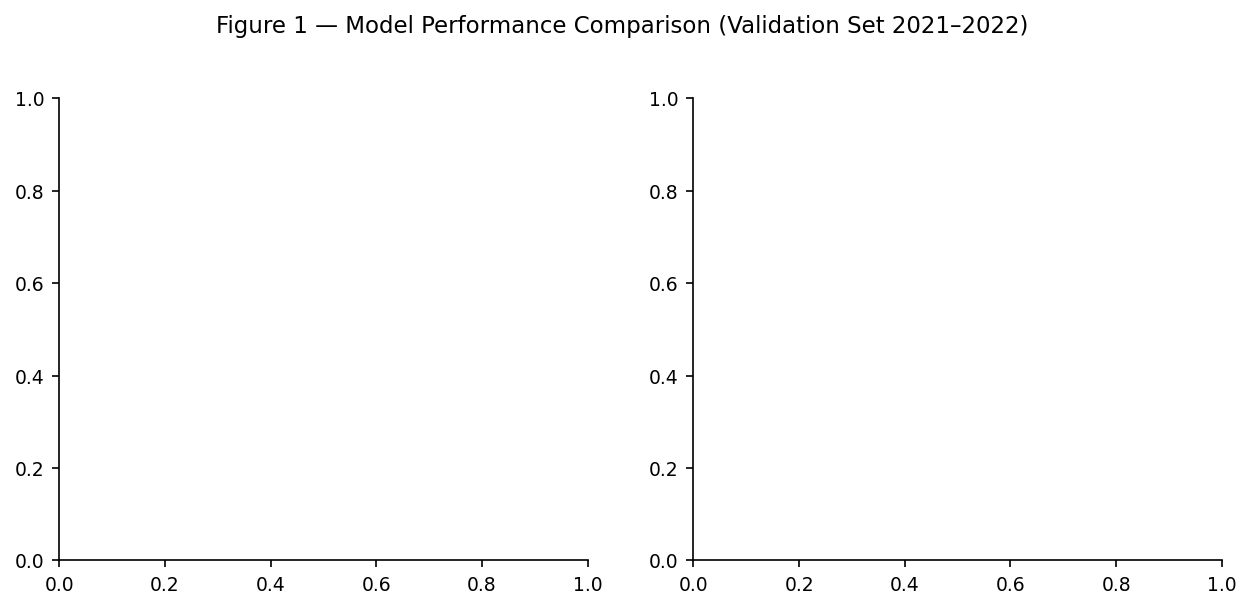

In [14]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import FancyBboxPatch
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay, classification_report
import pandas as pd
import numpy as np

plt.rcParams.update({
    'font.family': 'DejaVu Sans',
    'font.size': 10,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.labelsize': 10,
    'axes.titlesize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'figure.dpi': 150,
})

BLUE  = '#185FA5'
LBLUE = '#B5D4F4'
GREEN = '#3B6D11'
RED   = '#A32D2D'
LRED  = '#F09595'
GRAY  = '#888780'

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle('Figure 1 — Model Performance Comparison (Validation Set 2021–2022)',
             fontsize=11, y=1.02)

models = ['Random Forest', 'XGBoost', 'LightGBM', 'MLP', 'CatBoost', 'Logistic Reg.']
aucs   = [roc_auc_score(y_val, y_pred_rf),
          roc_auc_score(y_val, y_pred_xgb),
          roc_auc_score(y_val, y_pred_lgb),
          roc_auc_score(y_val, y_pred_mlp),
          roc_auc_score(y_val, y_pred_cat),
          roc_auc_score(y_val, y_pred_lr)]
auprcs = [average_precision_score(y_val, y_pred_rf),
          average_precision_score(y_val, y_pred_xgb),
          average_precision_score(y_val, y_pred_lgb),
          average_precision_score(y_val, y_pred_mlp),
          average_precision_score(y_val, y_pred_cat),
          average_precision_score(y_val, y_pred_lr)]
colors_bar = [LBLUE, LBLUE, BLUE, LBLUE, LBLUE, LBLUE]

for ax, vals, ylabel, baseline, title in zip(
    axes,
    [aucs, auprcs],
    ['ROC-AUC', 'AUPRC'],
    [0.5, 0.196],
    ['ROC-AUC', 'AUPRC']
):
    bars = ax.bar(models, vals, color=colors_bar, width=0.5, edgecolor='white', linewidth=1)
    ax.axhline(y=baseline, color=GRAY, linestyle='--', linewidth=1,
               label=f'Random baseline ({baseline:.3f})', alpha=0.7)
    ax.set_ylabel(ylabel)
    ax.set_ylim(min(vals) - 0.08, max(vals) + 0.04)
    ax.legend(fontsize=8, frameon=False)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='normal')
    ax.set_title(title)
    ax.tick_params(axis='x', length=0)

plt.tight_layout()
plt.savefig('outputs/fig1_model_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig1_model_comparison.png")

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ConfusionMatrixDisplay.from_predictions(
    y_val, (y_pred_lgb > 0.5).astype(int),
    ax=ax, cmap='Blues',
    display_labels=['Susceptible', 'Resistant'],
    colorbar=False
)
ax.set_title('Figure 2 — Confusion Matrix\nLightGBM · Validation Set 2021–2022', pad=10)
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
plt.tight_layout()
plt.savefig('outputs/fig2_confusion_matrix.png', dpi=200, bbox_inches='tight')
plt.show()

report = classification_report(y_val, (y_pred_lgb > 0.5).astype(int),
                                target_names=['Susceptible', 'Resistant'], digits=4)
print(report)
print("Saved: fig2_confusion_matrix.png")

feature_labels = {
    'antibiotic':                   'Antibiotic',
    'organism':                     'Organism',
    'gdp_per_capita_usd':           'GDP per capita (USD)',
    'population_density_per_sq_km': 'Population density',
    'health_expenditure_pct_gdp':   'Health expenditure (% GDP)',
    'year':                         'Year',
    'consumption_ddd_per_1000_day': 'Antibiotic consumption (DDD/1000/day)',
}
imp_vals = model_final.feature_importances_
imp_norm = imp_vals / imp_vals.max()
imp_df = pd.DataFrame({
    'feature': [feature_labels.get(f, f) for f in FEATURES],
    'importance': imp_norm
}).sort_values('importance', ascending=True)

fig, ax = plt.subplots(figsize=(8, 4))
colors_feat = [BLUE if v > 0.5 else LBLUE if v > 0.15 else '#E6F1FB' for v in imp_df['importance']]
bars = ax.barh(imp_df['feature'], imp_df['importance'],
               color=colors_feat, edgecolor='white', linewidth=0.5, height=0.55)
ax.bar_label(bars, fmt='%.3f', padding=4, fontsize=9, color=GRAY)
ax.set_xlim(0, 1.12)
ax.set_xlabel('Normalized gain importance')
ax.set_title('Figure 3 — Feature Importance (Gain)\nLightGBM final model · Zero-Shot Kazakhstan prediction')
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.savefig('outputs/fig3_feature_importance.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig3_feature_importance.png")

loco_sorted = loco_df.sort_values('AUC', ascending=True)
fig, ax = plt.subplots(figsize=(8, 4))
bar_colors = [BLUE if c == 'Russia' else LBLUE for c in loco_sorted['country']]
bars = ax.barh(loco_sorted['country'], loco_sorted['AUC'],
               color=bar_colors, edgecolor='white', linewidth=0.5, height=0.55)
ax.axvline(x=loco_df['AUC'].mean(), color=GRAY, linestyle='--', linewidth=1.2,
           label=f"Mean = {loco_df['AUC'].mean():.4f}", alpha=0.8)
ax.bar_label(bars, fmt='%.4f', padding=3, fontsize=9, color=GRAY)
ax.set_xlim(0.82, 0.905)
ax.set_xlabel('ROC-AUC')
ax.set_title('Figure 4 — LOCO Validation\nZero-shot AUC by proxy country (Russia = primary KZ proxy)')
ax.legend(fontsize=9, frameon=False)
ax.tick_params(axis='y', length=0)
plt.tight_layout()
plt.savefig('outputs/fig4_loco_validation.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig4_loco_validation.png")

fig, ax = plt.subplots(figsize=(8, 4))
fold_labels = [f"F{r['fold']}\n{r['train_years'].split('–')[0]}→{r['val_years']}"
               for _, r in cv_df.iterrows()]
ax.plot(fold_labels, cv_df['AUC'],   'o-', color=BLUE,  linewidth=2, markersize=6, label='AUC')
ax.plot(fold_labels, cv_df['AUPRC'], 's--', color=GREEN, linewidth=1.5, markersize=5, label='AUPRC')
ax.fill_between(fold_labels, cv_df['AUC'], alpha=0.08, color=BLUE)
for i, (_, row) in enumerate(cv_df.iterrows()):
    ax.annotate(f"{row['AUC']:.4f}", (i, row['AUC']), textcoords='offset points',
                xytext=(0, 8), ha='center', fontsize=8, color=BLUE)
ax.set_ylim(0.50, 0.94)
ax.set_xlabel('Fold (training window \u2192 validation window)', fontsize=11)

In [18]:
# SECTION A — Naive Baseline Comparison

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
from sklearn.preprocessing import LabelEncoder
from lightgbm import LGBMClassifier

# ── Load & clean
_raw = pd.read_csv('outputs/full_amr_with_macro.csv', low_memory=False)
_raw = _raw[~_raw['country'].isin(['Kazakhstan'])].copy()

# Drop ALL duplicate columns
_raw = _raw.loc[:, ~_raw.columns.duplicated()]

# Build required_cols safely — only keep cols that actually exist & are unique
_required = ['isolate_id', 'country', 'year', 'resistance'] + FEATURES
_required = list(dict.fromkeys(_required))          
_required = [c for c in _required if c in _raw.columns]

source_df    = _raw[_required].copy()
source_sorted = source_df.sort_values('year').reset_index(drop=True)

train_df = source_sorted[source_sorted['year'] <= 2020].copy()
val_df   = source_sorted[(source_sorted['year'] > 2020) & (source_sorted['year'] <= 2022)].copy()

print(f"Train: {len(train_df):,}  |  Val: {len(val_df):,}")

#Encode categoricals (fit on train only)
X_train_bl = train_df[FEATURES].copy()
X_val_bl   = val_df[FEATURES].copy()
y_train    = train_df['resistance'].copy()
y_val      = val_df['resistance'].copy()

for col in CAT_FEATURES:
    le = LabelEncoder()
    X_train_bl[col] = le.fit_transform(X_train_bl[col].fillna('unknown').astype(str))
    le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
    X_val_bl[col]   = X_val_bl[col].fillna('unknown').astype(str).map(
        lambda s, d=le_dict: d.get(s, -1)
    )

#Train LightGBM for baseline comparison
spw = (y_train == 0).sum() / (y_train == 1).sum()
_lgb_bl = LGBMClassifier(
    n_estimators=1000, learning_rate=0.05, max_depth=6,
    num_leaves=32, scale_pos_weight=spw, random_state=42, verbose=-1
)
_lgb_bl.fit(X_train_bl, y_train)
y_pred_lgb = _lgb_bl.predict_proba(X_val_bl)[:, 1]

#Baseline 1: Random Chance
global_prev   = y_train.mean()
y_base_random = np.full(len(y_val), global_prev)

#Baseline 2: Global antibiotic mean (train only)
ab_mean_train  = train_df.groupby('antibiotic')['resistance'].mean().rename('ab_mean').reset_index()
val_with_base  = val_df[['antibiotic', 'organism', 'resistance']].copy()
val_with_base  = val_with_base.merge(ab_mean_train, on='antibiotic', how='left')
val_with_base['ab_mean'] = val_with_base['ab_mean'].fillna(global_prev)
y_base_ab_mean = val_with_base['ab_mean'].values

#Baseline 3: (Organism × Antibiotic) group mean (train only)
org_ab_mean    = train_df.groupby(['organism', 'antibiotic'])['resistance'].mean().rename('org_ab_mean').reset_index()
val_with_base  = val_with_base.merge(org_ab_mean, on=['organism', 'antibiotic'], how='left')
val_with_base['org_ab_mean'] = val_with_base['org_ab_mean'].fillna(val_with_base['ab_mean'])
y_base_org_ab  = val_with_base['org_ab_mean'].values

#Metrics
def safe_metrics(y_true, y_prob, name):
    auc   = roc_auc_score(y_true, y_prob)
    auprc = average_precision_score(y_true, y_prob)
    lift  = auc / 0.5
    print(f"  {name:<38s}  AUC={auc:.4f}  AUPRC={auprc:.4f}  lift={lift:.3f}x")
    return {'model': name, 'AUC': auc, 'AUPRC': auprc, 'lift_over_random': lift}

print("\n=== Naive Baseline Comparison (Validation 2021–2022) ===")
baseline_rows = [
    safe_metrics(y_val, y_base_random,  "Baseline 1: Random Chance"),
    safe_metrics(y_val, y_base_ab_mean, "Baseline 2: Global Antibiotic Mean"),
    safe_metrics(y_val, y_base_org_ab,  "Baseline 3: Organism×Antibiotic Mean"),
    safe_metrics(y_val, y_pred_lgb,     "LightGBM Zero-Shot (full model)"),
]
baseline_df = pd.DataFrame(baseline_rows)
print()
print(baseline_df.to_string(index=False))
baseline_df.to_csv('outputs/baseline_comparison.csv', index=False)

#Figure 5: Baseline comparison
BLUE  = '#185FA5'
LBLUE = '#B5D4F4'
GREEN = '#3B6D11'
GRAY  = '#888780'

fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
fig.suptitle('Figure 5 — LightGBM vs. Naive Baselines (Validation Set 2021–2022)',
             fontsize=11, y=1.02)

bar_colors = [LBLUE, LBLUE, LBLUE, BLUE]
bar_names  = ['Random\nChance', 'Antibiotic\nMean', 'Org×Ab\nMean', 'LightGBM\nZero-Shot']

for ax, metric, rand_val, title in zip(
    axes,
    ['AUC', 'AUPRC'],
    [0.5, global_prev],
    ['ROC-AUC', 'AUPRC']
):
    vals = baseline_df[metric].tolist()
    bars = ax.bar(bar_names, vals, color=bar_colors, width=0.5, edgecolor='white', linewidth=1)
    ax.axhline(y=rand_val, color=GRAY, linestyle='--', linewidth=1,
               label=f'Random ({rand_val:.3f})', alpha=0.7)
    ax.set_ylim(max(0, min(vals) - 0.08), min(1, max(vals) + 0.06))
    ax.set_ylabel(title)
    ax.set_title(title)
    ax.legend(fontsize=8, frameon=False)
    ax.tick_params(axis='x', length=0)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.003,
                f'{val:.4f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig('outputs/fig5_baseline_comparison.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig5_baseline_comparison.png")



# SECTION B — Feature Ablation Analysis

ABLATION_CONFIGS = [
    {'name': 'Full model (all features)',  'drop': []},
    {'name': '− GDP per capita',           'drop': ['gdp_per_capita_usd']},
    {'name': '− Health expenditure',       'drop': ['health_expenditure_pct_gdp']},
    {'name': '− Population density',       'drop': ['population_density_per_sq_km']},
    {'name': '− Year',                     'drop': ['year']},
    {'name': '− All macro features',       'drop': ['gdp_per_capita_usd',
                                                     'health_expenditure_pct_gdp',
                                                     'population_density_per_sq_km']},
    {'name': '− Organism',                 'drop': ['organism']},
    {'name': '− Antibiotic',               'drop': ['antibiotic']},
]

def run_ablation(train_df, val_df, feature_list, cat_features, config):
    active_features = [f for f in feature_list if f not in config['drop']]
    active_cat      = [f for f in cat_features  if f not in config['drop']]

    X_tr = train_df[active_features].copy()
    X_vl = val_df[active_features].copy()
    y_tr = train_df['resistance']
    y_vl = val_df['resistance']

    for col in active_cat:
        le = LabelEncoder()
        X_tr[col] = le.fit_transform(X_tr[col].fillna('unknown').astype(str))
        le_dict = dict(zip(le.classes_, le.transform(le.classes_)))
        X_vl[col] = X_vl[col].fillna('unknown').astype(str).map(
            lambda s, d=le_dict: d.get(s, -1)
        )

    spw   = (y_tr == 0).sum() / (y_tr == 1).sum()
    model = LGBMClassifier(n_estimators=1000, learning_rate=0.05, max_depth=6,
                           num_leaves=32, scale_pos_weight=spw, random_state=42, verbose=-1)
    model.fit(X_tr, y_tr)

    y_prob = model.predict_proba(X_vl)[:, 1]
    return roc_auc_score(y_vl, y_prob), average_precision_score(y_vl, y_prob), active_features


print("\n=== Feature Ablation Analysis ===")
ablation_rows = []
for cfg in ABLATION_CONFIGS:
    auc, auprc, used = run_ablation(train_df, val_df, FEATURES, CAT_FEATURES, cfg)
    ablation_rows.append({'config': cfg['name'], 'n_feat': len(used),
                          'AUC': auc, 'AUPRC': auprc, 'features': ', '.join(used)})
    flag = 'reference' if cfg['name'].startswith('Full') else ''
    print(f"  {cfg['name']:<38s}  n={len(used)}  AUC={auc:.4f}  AUPRC={auprc:.4f}{flag}")

ablation_df = pd.DataFrame(ablation_rows)
ablation_df.to_csv('outputs/ablation_results.csv', index=False)

full_auc   = ablation_df.loc[ablation_df['config'].str.startswith('Full'), 'AUC'].values[0]
full_auprc = ablation_df.loc[ablation_df['config'].str.startswith('Full'), 'AUPRC'].values[0]
ablation_df['delta_AUC']   = ablation_df['AUC']   - full_auc
ablation_df['delta_AUPRC'] = ablation_df['AUPRC'] - full_auprc

print("\nAUC drop vs. full model:")
print(ablation_df[['config', 'delta_AUC', 'delta_AUPRC']].to_string(index=False))

# ── Figure 6: Ablation chart ──────────────────────────────────────────────────
plot_df = ablation_df.sort_values('AUC', ascending=True).reset_index(drop=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Figure 6 — Feature Ablation Analysis\n'
             'LightGBM trained on source domain (<=2020), evaluated on validation (2021–2022)',
             fontsize=11, y=1.02)

for ax, metric, ref_val, xlabel in zip(
    axes,
    ['AUC', 'AUPRC'],
    [full_auc, full_auprc],
    ['ROC-AUC', 'AUPRC']
):
    vals  = plot_df[metric].tolist()
    names = plot_df['config'].tolist()
    bar_cols = [BLUE if n.startswith('Full') else ('#F09595' if v < ref_val - 0.02 else LBLUE)
                for n, v in zip(names, vals)]

    bars = ax.barh(names, vals, color=bar_cols, height=0.6, edgecolor='white', linewidth=0.8)
    ax.axvline(x=ref_val, color=BLUE, linestyle='--', linewidth=1.2,
               label=f'Full model ({ref_val:.4f})', alpha=0.8)

    for bar, val, name in zip(bars, vals, names):
        delta     = val - ref_val
        delta_str = f'Δ{delta:+.4f}' if not name.startswith('Full') else 'reference'
        ax.text(max(vals) + 0.002, bar.get_y() + bar.get_height() / 2,
                delta_str, va='center', fontsize=8,
                color='#A32D2D' if delta < -0.02 else GRAY)

    ax.set_xlim(min(vals) - 0.04, max(vals) + 0.07)
    ax.set_xlabel(xlabel)
    ax.set_title(xlabel)
    ax.legend(fontsize=8, frameon=False)
    ax.tick_params(axis='y', length=0)

plt.tight_layout()
plt.savefig('outputs/fig6_ablation_analysis.png', dpi=200, bbox_inches='tight')
plt.show()
print("Saved: fig6_ablation_analysis.png")

#Summary table
print("\n Summary Table for Results Section")
summary = ablation_df[['config', 'n_feat', 'AUC', 'AUPRC', 'delta_AUC']].copy()
summary.columns = ['Configuration', 'N features', 'AUC', 'AUPRC', 'ΔAUC vs full']
print(summary.to_string(index=False))
summary.to_csv('outputs/table2_ablation_summary.csv', index=False)

Train: 9,755,320  |  Val: 1,892,959


KeyboardInterrupt: 